In [1]:
# import packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# import time averaging and mixing functions
from timeAvgFunction import iceTimeAvg
from mixFunction import mixIce

# set plot styles
import matplotlib as mpl
mpl.rcParams['lines.linewidth'] = 1
mpl.rcParams['lines.linestyle'] = '-'
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Helvetica']
mpl.rcParams['font.size'] = 9
mpl.rcParams['axes.linewidth'] = .5

#silence warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
# load ice data
ice = pd.read_excel("blueIceData.xlsx")
# remove deepest sample which isn't considered in the original paper
ice = ice.iloc[:-1]
# we want to work with just the long snapshot data
ice = ice.loc[ice['SnapshotLong']==1].reset_index(drop=True)

## Section 1: Mixing depth determination for CO<sub>2</sub>

In [3]:
######## Make the null hypothesis "truth" CO2 dataset
# Set a threshold to remove really low (unrealistic) alkenone and paleosol proxy values.
# Using 160 here bc min CO2 from the 800 ka traditional ice core record is 173 ppm.
lowThres = 160
# Set the cutoff point in time to find and compile proxy CO2 data (in ka)
timeCut = 3800
# first load 800 ka record of traditional ice core CO2
co2 = pd.read_csv("externalData/antarctica2015co2composite-noaa.txt",sep='\t')
co2age = co2['age_gas_calBP'].to_numpy()/1000
co2ppm = co2['co2_ppm'].to_numpy()
# then load boron data - from paleo-co2.org compilation
bdata = pd.read_csv("externalData/boron_co2.csv").sort_values(by='age')
# clip to timeCut value
bdataPlio = bdata.loc[bdata['age']<timeCut].reset_index(drop=True)
ageBoron = bdataPlio["age"].to_numpy()
co2Boron = bdataPlio["co2"].to_numpy()
# load paleosol co2 data - from paleo-co2.org compilation
pdata = pd.read_csv("externalData/paleosol_co2.csv").sort_values(by='age')
# remove data points below threshold value
pdata = pdata.loc[pdata["co2"]>lowThres].reset_index(drop=True)
agePaleo = pdata["age"].to_numpy()
co2Paleo = pdata["co2"].to_numpy()
# load alkenone co2 data - from paleo-co2.org compilation
alkCO2 = pd.read_csv("externalData/alkenone_co2.csv")
# clip and remove data points below threshold value
alkCO2 = alkCO2.loc[(alkCO2['age']<timeCut) & (alkCO2['co2']>lowThres)].reset_index(drop=True)
ageAlk = alkCO2["age"].to_numpy()
co2Alk = alkCO2["co2"].to_numpy()
# make a composite CO2 record using ice for < 800 ka then other proxies beyond
# boron
bages = ageBoron[ageBoron > co2age.max()]
bdats = co2Boron[ageBoron > co2age.max()]
# alkenone
aages = ageAlk[ageAlk > co2age.max()]
adats = co2Alk[ageAlk > co2age.max()]
# paleosol is only 1-3 Ma so doesn't need clipping
# concatenate together
compCO2age = np.concatenate((co2age,bages,agePaleo,aages))
compCO2 = np.concatenate((co2ppm,bdats,co2Paleo,adats))
indices = np.argsort(compCO2age)
compCO2age = compCO2age[indices]
compCO2 = compCO2[indices]
# resample the dataset to an even time step to avoid aliasing during forward modeling
# let's do 10 ka
tstep = 10
CO2dAge = np.arange(0,np.max(compCO2age),tstep)
CO2dVal = np.interp(CO2dAge,compCO2age,compCO2)

In [4]:
######### TIME AVERAGING 
# apply the time averaging function
CO2sim = iceTimeAvg(ice.Age, ice.AgeErrA, 200, CO2dAge,CO2dVal,1000)

###### MIXING
# compute middle depth
dmid = ice[['TopDepth', 'BottomDepth']].mean(axis=1)
# mix co2, use 10 cm as the dstep (mean sample width)
dstep = 0.1
mixTestC = np.array([0.5,0.55,.6,.65,.7,.75,.8,.85,.9,.95,1,1.05,1.1])
mixArrayC = np.zeros((CO2sim.shape[0],CO2sim.shape[1],len(mixTestC)))
# test different mixing depths
for i in range(len(mixTestC)):
    _, _, _, mixNow = mixIce(dmid,dstep,CO2sim,mixTestC[i])
    mixArrayC[:,:,i] = mixNow

In [5]:
######## COMPUTE VARIANCES (AND OTHER STATS)
co2pres = ~np.isnan(ice.CO2m)
prist = ice.NotPristine == 0
co2p = ice.CO2m[prist]
co2p = np.where(~np.isnan(ice.CO2dC[prist]), ice.CO2dC[prist], ice.CO2m[prist])
agep = ice.Age[prist]
compDats = co2p[(~np.isnan(co2p))]
idx = prist & co2pres

# data variance
icevarC = np.var(compDats, ddof=1)
icevarerrC = np.sqrt((2 * (icevarC**2)) / (len(compDats) - 1))

# simulated variance and other stats
simvarC = np.zeros((len(mixTestC)))
for i in range(len(mixTestC)):
    simvarC[i] = np.var(mixArrayC[idx,:,i], ddof=1)


## Section 2: Mixing depth determination for d2H in ice

In [6]:
###### CREATE D2H NULL "TRUTH" DATASET
# read in lr04 and also Epica Dome C dD data
lr04 = pd.read_excel("externalData/lisiecki2005-d18o-stack-noaa.xlsx")
edcD = pd.read_excel("externalData/edc3deuttemp2007-noaa.xlsx")
# normalize LR04 in the same age range as EDC
lrCut = lr04.loc[lr04['Age']<= max(edcD.Age/1000)]
lrNorm = -(lr04.d18Ob - np.mean(lrCut.d18Ob))/np.std(lrCut.d18Ob)
# add back stdev from EDC Deuterium, adjust mean to match the group of blue ice measurements younger than 800 ka (EDC span)
lrEDC = lrNorm * np.std(edcD.Deuterium) + np.mean(ice.dDice[ice.Age < 800])
ageLR04 = lr04['Age'].to_numpy()

In [7]:
###### TIME AVERAGING AND MIXING OF D2H
dDSim = iceTimeAvg(ice.Age, ice.AgeErrA, 200, ageLR04,lrEDC,1000)
# mix - sample step is still 10 cm as with CO2
mixTestD = np.array([0.05,0.1,.15,.2,.25,.3,.35,.4,.45,.5,.55,.6,.65,.7])
mixArrayD = np.zeros((dDSim.shape[0],dDSim.shape[1],len(mixTestD)))
# test different mixing depths
for i in range(len(mixTestD)):
    _, _, _, mixNow = mixIce(dmid,dstep,dDSim,mixTestD[i])
    mixArrayD[:,:,i] = mixNow

In [8]:
######## COMPUTE VARIANCES (AND OTHER STATS)
dDpres = ~np.isnan(ice.dDice)
dDats = ice.dDice[dDpres]
# data variance
icevarD = np.var(dDats,ddof=1)
icevarerrD = np.sqrt((2 * (icevarD**2)) / (len(dDats) - 1))

simvarD = np.zeros((len(mixTestD)))
# simulated variance and other stats
for i in range(len(mixTestD)):
    simvarD[i] = np.var(mixArrayD[dDpres,:,i], ddof=1)

## Section 3: Iteration of mixing depth for MOT

In [9]:
###### CREATE NULL TRUTH DATASET FOR MOT
# for this we will first forward model from a "truth" MOT record based on scaling LR04 to EDC MOT (from Kr/N2)
# read in lr04 and also EDC dD data
edcMOT = pd.read_excel("externalData/edc2021noblegastemp.xlsx")
# normalize LR04 in the same age range as EDC
lrCut = lr04.loc[lr04['Age']<= max(edcMOT.Age)]
lrNorm = -(lr04.d18Ob - np.mean(lrCut.d18Ob))/np.std(lrCut.d18Ob)
# add back stdev from EDC Deuterium, adjust mean to match the youngest group of MOT measurements
lrMOT = lrNorm * np.std(edcMOT.MOTKrN2) + np.mean(ice.MOT[ice.Age < 800])

In [10]:
######## TIME AVERAGING AND MIXING OF MOT
# time average
MOTSim = iceTimeAvg(ice.Age, ice.AgeErrA, 200, ageLR04, lrMOT, 1000)
# mix - sample step is still 10 cm as with CO2
mixTestM = np.array([0.05,.1,.15,.2,.25,.3,.35,.4,.45,.5,.55,.6,.65])
mixArrayM = np.zeros((MOTSim.shape[0],MOTSim.shape[1],len(mixTestM)))
# test different mixing depths
for i in range(len(mixTestM)):
    _, _, _, mixNow = mixIce(dmid,dstep,MOTSim,mixTestM[i])
    mixArrayM[:,:,i] = mixNow
# in the case of MOT we need to add an additional error term associated with inference from Xe/Kr
# we can use the relative error column in the provided data set as a 1-sigma error
MOTpres = ~np.isnan(ice.MOT)
MOTdats = mixArrayM[MOTpres,:,:]
# MC sampling of this err
N = 1000
M = MOTdats.shape[0]
P = MOTdats.shape[2]
MOTerrs = np.atleast_2d(ice.MOTErr[MOTpres].to_numpy()).T
MOTerrs = np.repeat(MOTerrs,N,axis=1)
MOTerrs = np.tile(MOTerrs[:,:,np.newaxis],P)
MOTrndE = np.random.normal(np.zeros((M,N,P)),MOTerrs)#,size=(M,N,P))
# add error to final ensembles
MOTTot = MOTdats + MOTrndE

In [11]:
######## COMPUTE VARIANCES (AND OTHER STATS)
MOTDats = ice.MOT[MOTpres]
# data variance
icevarM = np.var(MOTDats,ddof=1)
icevarerrM = np.sqrt((2 * (icevarM**2)) / (len(MOTDats) - 1))

# simulated variance
simvarM = np.zeros((len(mixTestM)))
for i in range(len(mixTestM)):
    simvarM[i] = np.var(MOTTot[:,:,i], ddof=1)

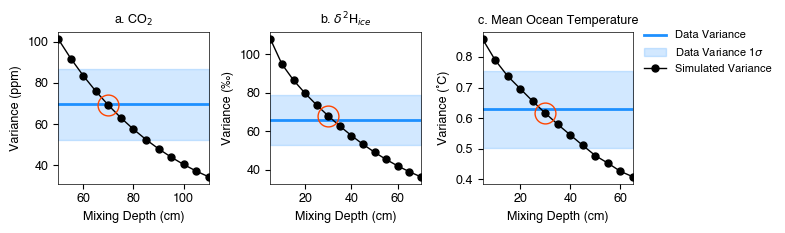

In [12]:
######### FIGURE S1
ms=5
#### CO2
cM = mixTestC*100
xlims = (np.min(cM),np.max(cM))
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(6.5, 2.4))
#### CO2
ax1.plot(cM,np.tile(icevarC,len(mixTestC)),color="dodgerblue",linewidth=2,zorder=2)
ax1.fill_between(cM,np.tile(icevarC,len(mixTestC))-icevarerrC,np.tile(icevarC,len(mixTestC))+icevarerrC,color="dodgerblue",alpha=.2,zorder=1)
ax1.plot(cM,simvarC,marker='o',markersize=ms,color="black",linewidth=1,zorder=3)
ax1.plot(cM[cM==70],simvarC[cM==70],marker='o',markerfacecolor="None",markeredgecolor="orangered",markersize=15,zorder=4)
ax1.set_xlim(xlims)
ax1.set_xlabel("Mixing Depth (cm)")
ax1.set_ylabel("Variance (ppm)")
ax1.set_title("a. CO$_2$",fontsize=9)

#### dD
cMd = mixTestD*100
xlims = (np.min(cMd),np.max(cMd))
ax2.plot(cMd,np.tile(icevarD,len(mixTestD)),color="dodgerblue",linewidth=2,zorder=2)
ax2.fill_between(cMd,np.tile(icevarD,len(mixTestD))-icevarerrD,np.tile(icevarD,len(mixTestD))+icevarerrD,color="dodgerblue",alpha=.2,zorder=1)
ax2.plot(cMd,simvarD,marker='o',markersize=ms,color="black",linewidth=1,zorder=3)
ax2.plot(cMd[cMd==30],simvarD[cMd==30],marker='o',markerfacecolor="None",markeredgecolor="orangered",markersize=15,zorder=4)
ax2.set_xlim(xlims)
ax2.set_xlabel("Mixing Depth (cm)")
ax2.set_ylabel("Variance (‰)")
ax2.set_title("b. $\delta^2$H$_{ice}$",fontsize=9)

#### MOT
cM = mixTestM*100
xlims = (np.min(cM),np.max(cM))

ax3.plot(cM,np.tile(icevarM,len(mixTestM)),color="dodgerblue",linewidth=2,label="Data Variance",zorder=2)
ax3.fill_between(cM,np.tile(icevarM,len(mixTestM))-icevarerrM,np.tile(icevarM,len(mixTestM))+icevarerrM,color="dodgerblue",alpha=.2,label="Data Variance 1$\sigma$",zorder=1)
ax3.plot(cM,simvarM,marker='o',markersize=ms,color="black",linewidth=1,label="Simulated Variance",zorder=3)
ax3.plot(cM[cM==30],simvarM[cM==30],marker='o',markerfacecolor="None",markeredgecolor="orangered",markersize=15,zorder=4)
ax3.set_xlim(xlims)
ax3.set_xlabel("Mixing Depth (cm)")
ax3.set_ylabel("Variance (˚C)")
ax3.set_title("c. Mean Ocean Temperature",fontsize=9)

fig.legend(frameon=False, fontsize=8, bbox_to_anchor=(.98, .9), loc='upper left')
fig.tight_layout()
fig.savefig("outputFigures/MixingDepthIteration.pdf", bbox_inches="tight")

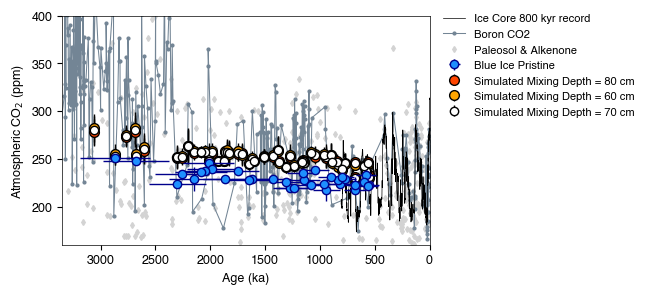

In [13]:
######## FIGURE S2 COMPARISON OF DIFFERENT MIXING CHOICES FOR CO2
ms=6
fig = plt.figure(figsize=(4.5,3))
ax = fig.add_subplot(1, 1, 1)
# background co2 proxy information
ax.plot(co2age,co2ppm,color="black",linewidth=0.5,label="Ice Core 800 kyr record",zorder=3)
ax.plot(ageBoron,co2Boron,color="xkcd:steel",linewidth=.75,marker='o',markersize=2, label="Boron CO2",zorder=2)
ax.plot(agePaleo,co2Paleo,color="lightgray",linewidth=.75,marker='d',markersize=3, linestyle="None",zorder=1,label="Paleosol & Alkenone")
ax.plot(ageAlk,co2Alk,color="lightgray",linewidth=.75,marker='d',markersize=3, linestyle="None",zorder=1)
ax.errorbar(agep,co2p,yerr=ice.CO2mErr[prist]*2,xerr=ice.AgeErrA[prist], markerfacecolor="dodgerblue",linestyle="None",
        markeredgecolor="darkblue",marker='o',markersize=ms, color="darkblue",label="Blue Ice Pristine",zorder=10)
ax.errorbar(ice.Age[co2pres],np.mean(mixArrayC[co2pres,:,mixTestC==.8],1),yerr=np.std(mixArrayC[co2pres,:,mixTestC==.8],1)*2,color="black",marker='o',linestyle='None',
        markeredgecolor="black",markerfacecolor="orangered",markersize=ms+1,label=f"Simulated Mixing Depth = {.8*100:.0f} cm",zorder=6)
ax.errorbar(ice.Age[co2pres],np.mean(mixArrayC[co2pres,:,mixTestC==.6],1),yerr=np.std(mixArrayC[co2pres,:,mixTestC==.65],1)*2,color="black",marker='o',linestyle='None',
        markeredgecolor="black",markerfacecolor="orange",markersize=ms+1,label=f"Simulated Mixing Depth = {.6*100:.0f} cm",zorder=6)
ax.errorbar(ice.Age[co2pres],np.mean(mixArrayC[co2pres,:,mixTestC==.7],1),yerr=np.std(mixArrayC[co2pres,:,mixTestC==.7],1)*2,color="black",marker='o',linestyle='None',
        markeredgecolor="black",markerfacecolor="white",markersize=ms,label=f"Simulated Mixing Depth = {.7*100:.0f} cm",zorder=6)
ax.set_xlim(0,3350)
ax.set_ylim(160,400)
fig.legend(frameon=False, fontsize=8, bbox_to_anchor=(.97, .98), loc='upper left')
ax.set_xlabel("Age (ka)")
ax.set_ylabel("Atmospheric CO$_2$ (ppm)")
ax.invert_xaxis()
fig.tight_layout()
fig.savefig("outputFigures/MixingDepthSensitivity.pdf", bbox_inches="tight")